# Projet: Analyse détaillée des prix de l'immobilier en Inde urbaine : tendances et perspectives

**Objectifs :**

- Comprendre l'ensemble de données et le nettoyer.
- Faire une analyse du marché immobilier et la modélisation prédictive
- Créez des modèles de régression pour prédire les ventes en fonction d'une ou plusieurs caractéristiques.
- Évaluez également les modèles et comparez leurs scores respectifs tels que R², RMSE, etc.
  
**Description du jeu de donnée:**

- Cet ensemble de données contient des informations détaillées sur les prix de l'immobilier résidentiel en Inde. Il comprend des caractéristiques telles que le **nombre de chambres** et de **salles de bains**, la **surface habitable** et la **superficie du terrain**, le **nombre d'étages**, la **proximité de l'eau**, **l'état et la catégorie de la maison**, les **années de construction et de rénovation**, ainsi que les **coordonnées géographiques**. D'autres caractéristiques incluent le nombre d'écoles à proximité, la distance de l'aéroport et le prix du bien.

- Le dataset provient du site **Kaggle.**

**Description des variables :**

- `id` : Identifiant unique pour chaque propriété.
- `Date` : Date à laquelle le bien a été mis en vente ou vendu.
- `number of bedrooms`: Nombre total de chambres dans la maison.
- `number of bathrooms`: Nombre total de salles de bains dans la maison.
- `living area`: La surface habitable totale en mètre carré.
- `lot area`: La superficie totale du terrain en mètre carré.
- `number of floors`: Nombre total d'étages dans la maison.
- `waterfront present`: Indique si la maison a une vue sur l'eau (1 pour oui, 0 pour non).
- `number of views`: Nombre de fois où le bien a été consulté.
- `condition of the house`: État général de la maison sur une échelle (ex. : 1 à 5).
- `grade of the house`: Niveau de la maison.
- `Area of the house(excluding basement)`: Surface de la maison (sous-sol exclu).
- `Area of the basement`: Niveau du sous-sol.
- `Built Year`: Année de construction.
- `Renovation Year`: Année de rénovation.
- `Postal Code`: Code Postal.
- `Lattitude`: Latitude.
- `Longitude`: Longitude.
- `living_area_renov`: Superficie habitable de la maison après rénovation..
- `lot_area_renov`: Superficie totale du terrain après rénovation.
- `Number of schools nearby`: Nombre d'écoles à proximité.
- `Distance from the airport`: Distance de l'aéroport.
- `Price`: Prix.


# Importons les bibliothèques

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/House Price India.csv')
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


# Nettoyage des données et analyse exploratoire

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

- Nous travaillons essentiellement avec des **variables numéques**.

In [6]:
df.isnull().sum()

,0
id,0
Date,0
number of bedrooms,0
number of bathrooms,0
living area,0
lot area,0
number of floors,0
waterfront present,0
number of views,0
condition of the house,0


- Notre dataset ne contient aucune variable **manquante**.

In [7]:
df.describe().round(2)

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,...,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00,14619.00
mean,6.762821e+09,42604.55,3.38,2.13,2098.16,15093.69,1.50,0.01,0.23,3.43,...,1970.93,90.93,122033.06,52.79,-114.40,1996.64,12754.00,2.01,64.95,538806.28
std,6.237160e+03,67.34,0.94,0.77,928.22,37920.89,0.54,0.09,0.77,0.66,...,29.49,416.23,19.08,0.14,0.14,691.08,26059.23,0.82,8.94,367229.36
min,6.762810e+09,42491.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,...,1900.00,0.00,122003.00,52.39,-114.71,460.00,651.00,1.00,50.00,78000.00
25%,6.762815e+09,42546.00,3.00,1.75,1440.00,5010.50,1.00,0.00,0.00,3.00,...,1951.00,0.00,122017.00,52.71,-114.52,1490.00,5097.50,1.00,57.00,320000.00
50%,6.762821e+09,42600.00,3.00,2.25,1930.00,7620.00,1.50,0.00,0.00,3.00,...,1975.00,0.00,122032.00,52.81,-114.42,1850.00,7620.00,2.00,65.00,450000.00
75%,6.762826e+09,42662.00,4.00,2.50,2570.00,10800.00,2.00,0.00,0.00,4.00,...,1997.00,0.00,122048.00,52.91,-114.32,2380.00,10125.00,3.00,73.00,645000.00
max,6.762832e+09,42734.00,33.00,8.00,13540.00,1074218.00,3.50,1.00,4.00,5.00,...,2015.00,2015.00,122072.00,53.01,-113.50,6110.00,560617.00,3.00,80.00,7700000.00


- Nous remarquons qu'il y aurait une maison avec **33 chambres**. C'est sans doute une erreur lors de l'enregistrement des données.

In [8]:
#Examinons des statistiques provenant de la colonne Price
round(df['Price'].describe().reset_index(), 2)

,index,Price
0,count,14619.00
1,mean,538806.28
2,std,367229.36
3,min,78000.00
4,25%,320000.00
5,50%,450000.00
6,75%,645000.00
7,max,7700000.00


- les prix **moyens** des maisons (538806.28) sont **largement supérieurs** au prix **médian** des maisons (450000). Cela veut dire qu'il y a de forte différence de prix entre les maisons.

In [9]:
#Vérifions s'il y a des lignes dupliquées dans notre dataset
print(df.duplicated().sum())

0


- Notre dataset ne comporte **aucune** ligne dupliquée

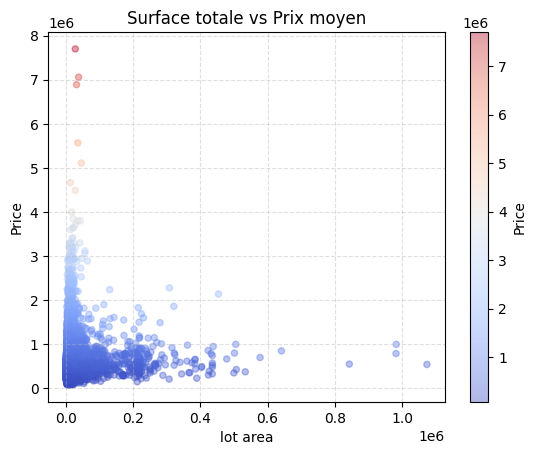

In [10]:
df.plot(kind='scatter', x='lot area', y='Price', c='Price', alpha=0.4, cmap='coolwarm')
plt.title('Surface totale vs Prix moyen')
plt.grid(True, alpha=0.4, linestyle='--')
plt.show()

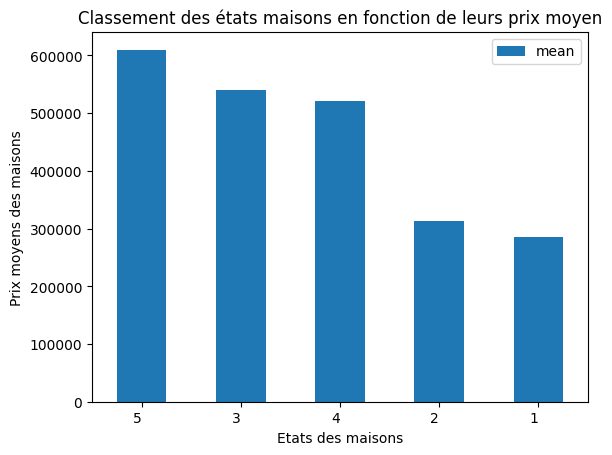

In [11]:
# Classement des états maisons en fonction de leurs prix moyens

df.groupby("condition of the house")["Price"].agg(['mean']).sort_values(by='mean', ascending=False).plot(kind = 'bar')
plt.title('Classement des états maisons en fonction de leurs prix moyen')
plt.ylabel('Prix moyens des maisons')
plt.xlabel('Etats des maisons')
plt.xticks(rotation=360, ha='right')
plt.show()

- Les maisons ayant un **meilleur état** valent plus **chères.**

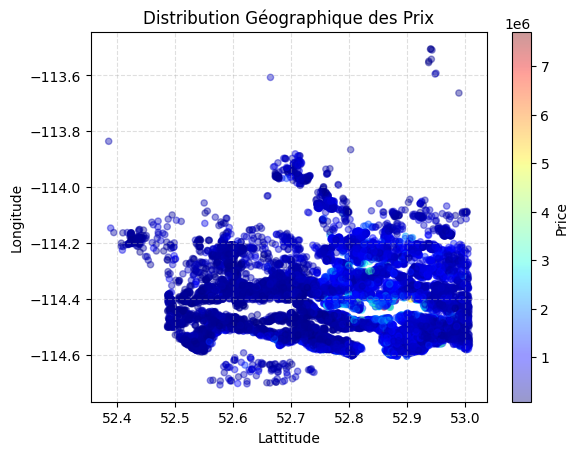

In [12]:
# Analyse spatiale
df.plot(kind = 'scatter', x = 'Lattitude', y = 'Longitude', c = 'Price', alpha=0.4, cmap='jet')
plt.title('Distribution Géographique des Prix')
plt.grid(True, alpha=0.4, linestyle='--')
plt.show()

- Les maisons avec une lattitude entre **52 et 53** sont les plus **chères**.

In [13]:
cols = df.columns
cols

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

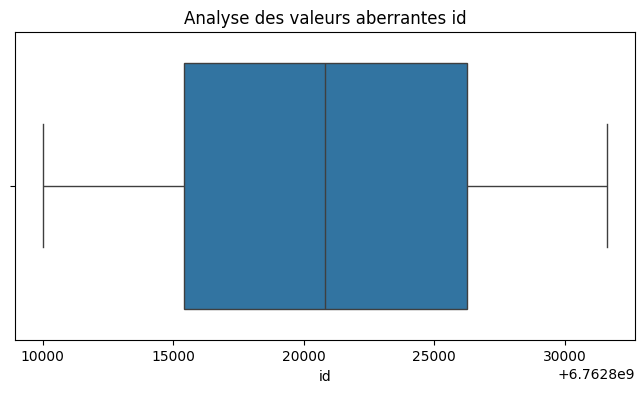

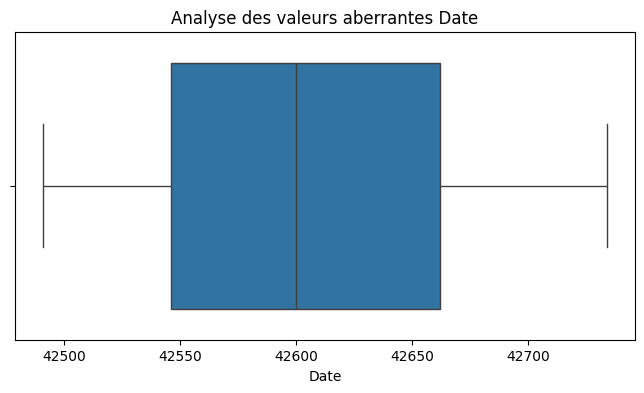

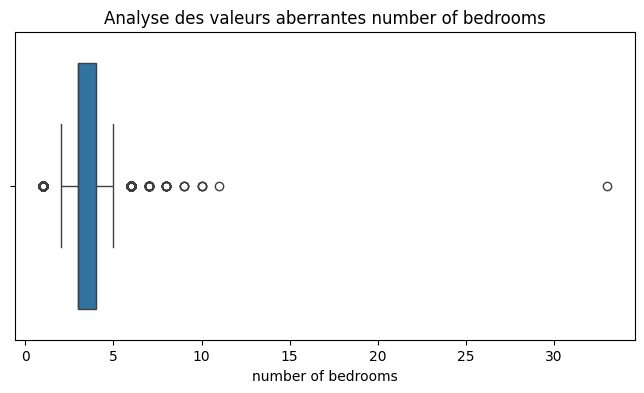

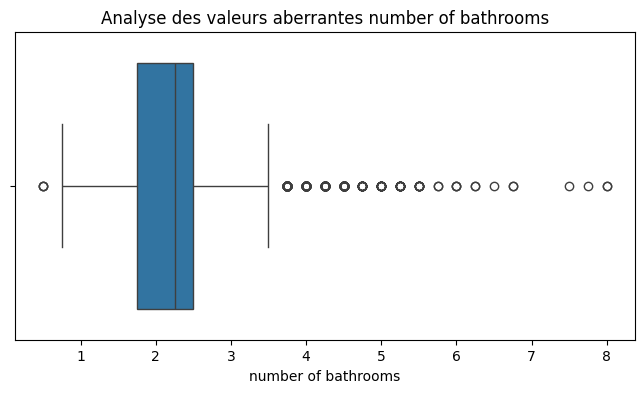

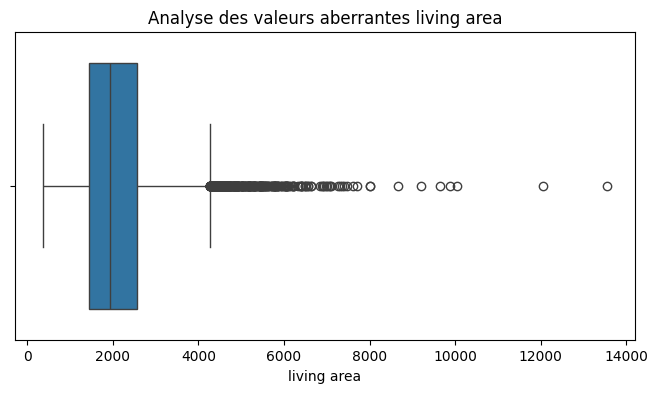

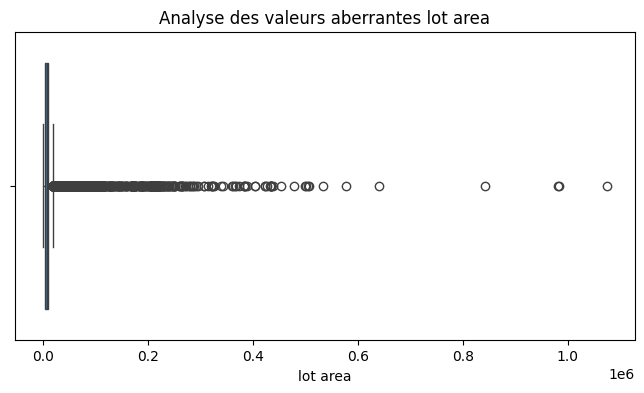

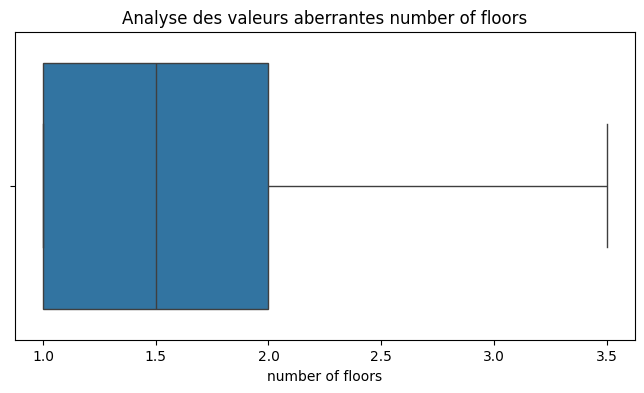

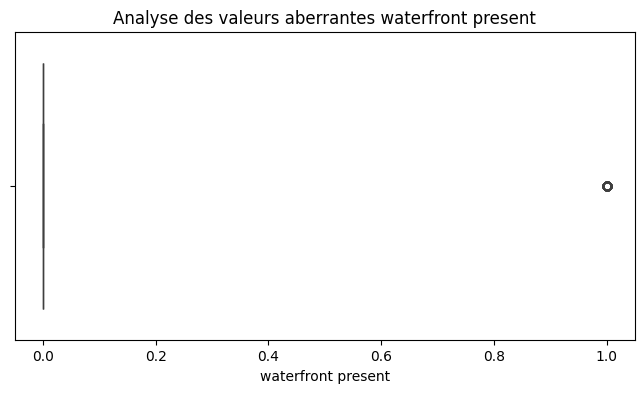

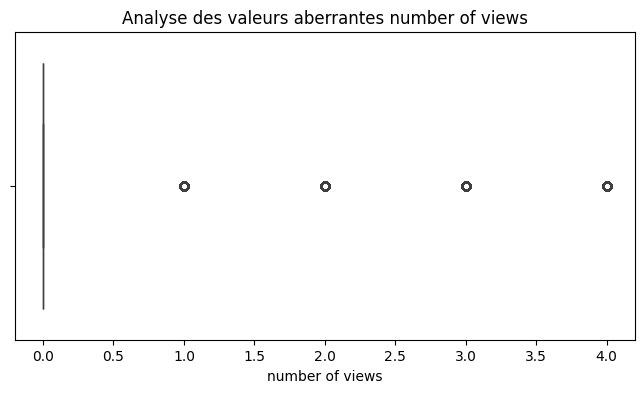

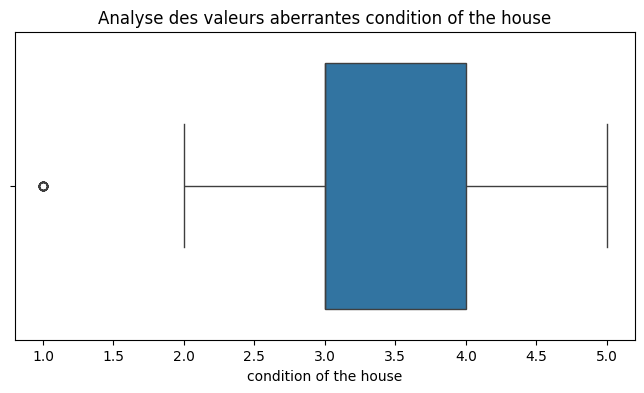

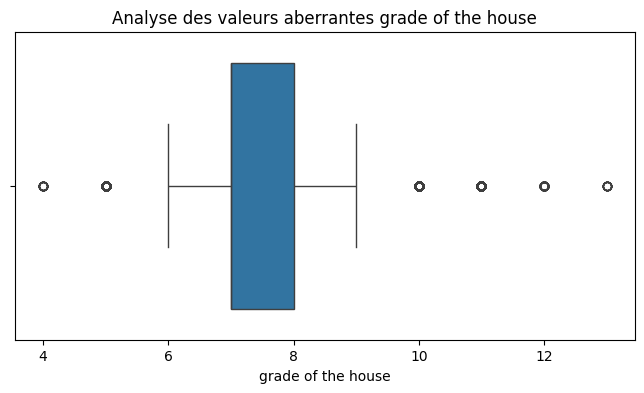

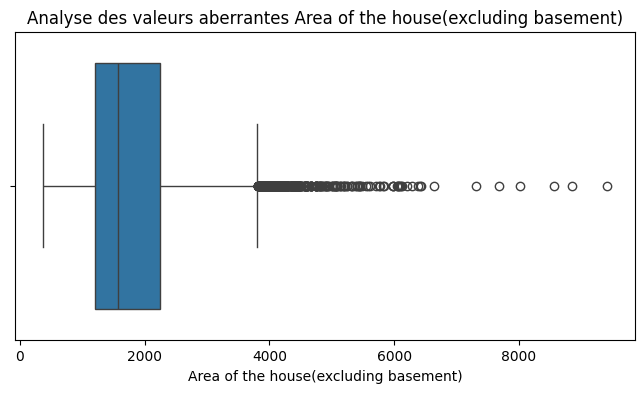

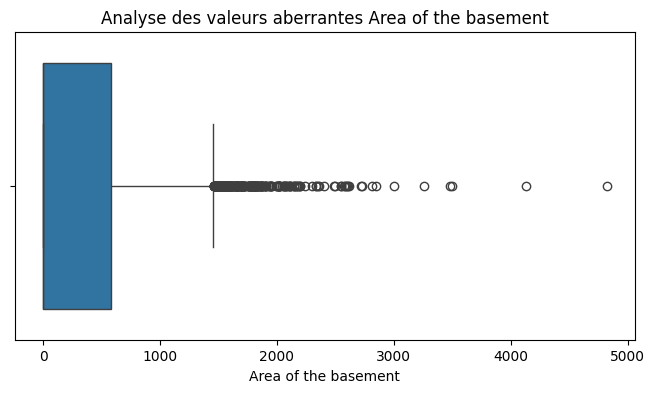

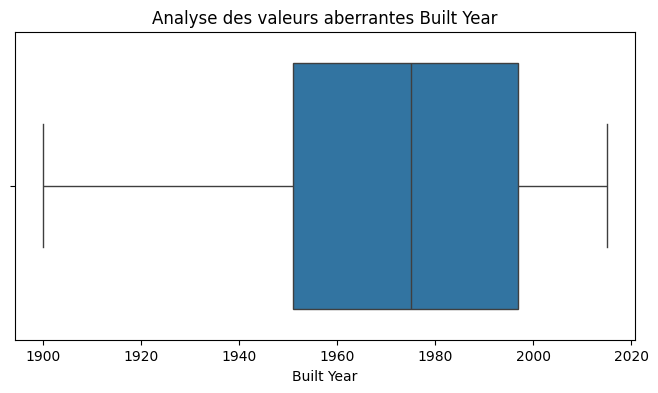

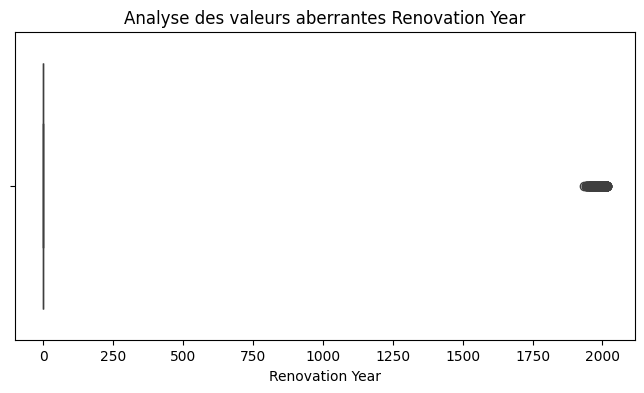

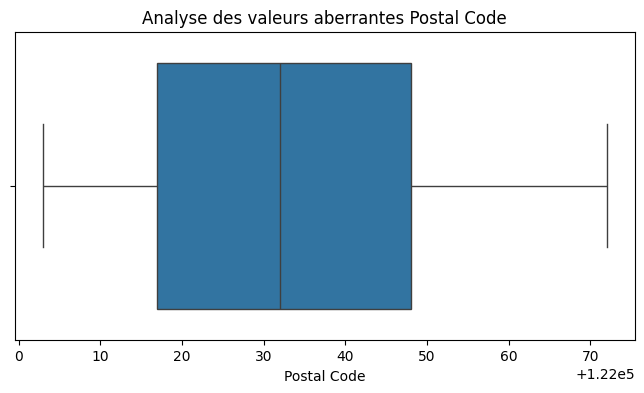

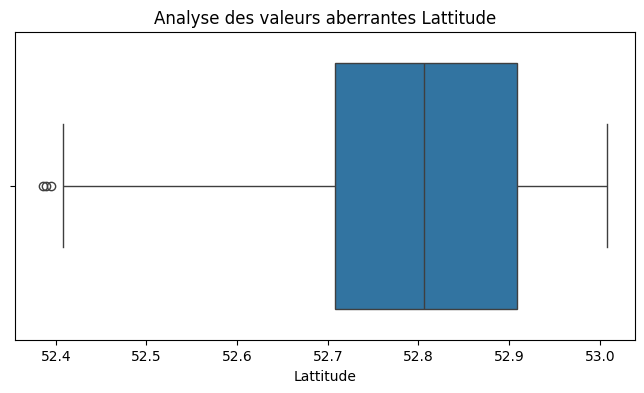

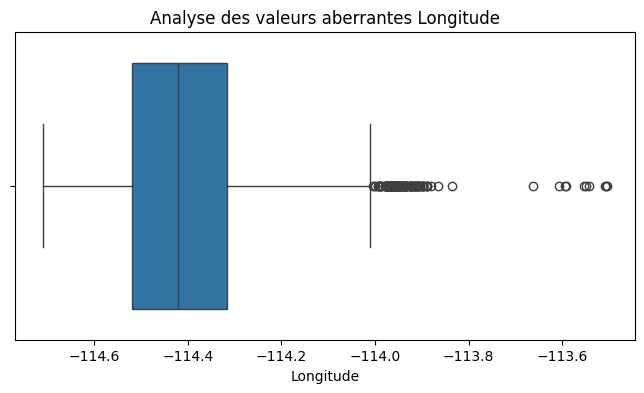

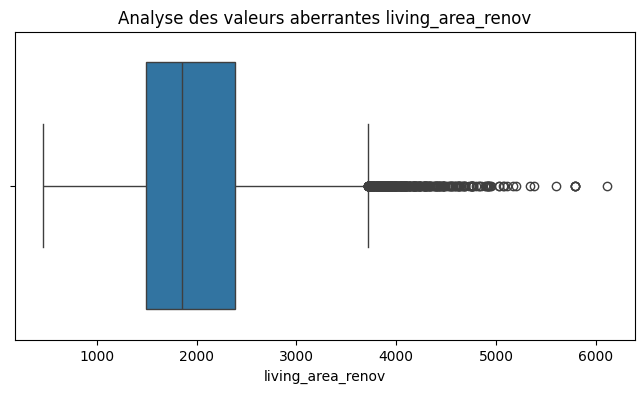

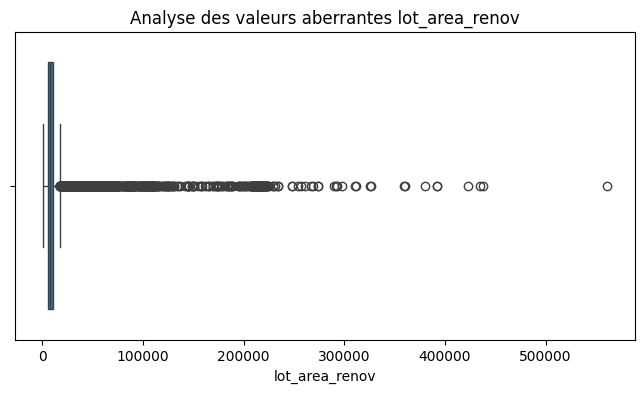

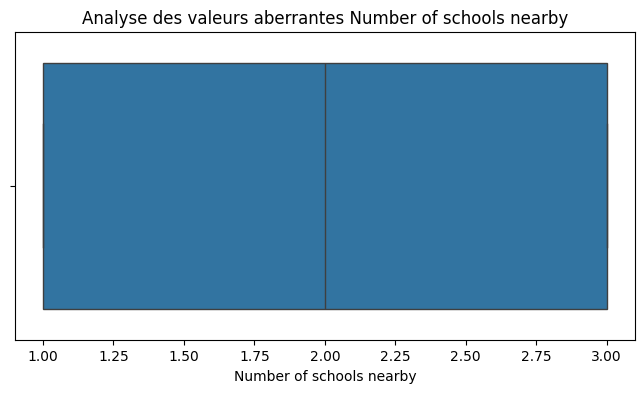

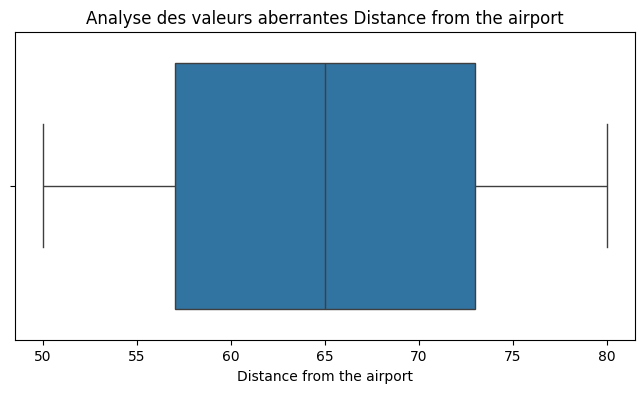

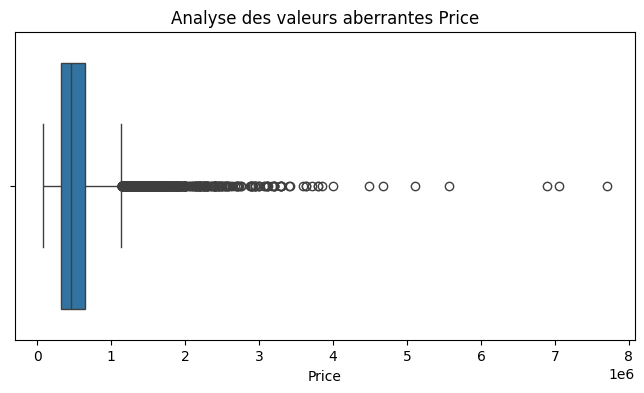

In [14]:
for col in cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Analyse des valeurs aberrantes {col}")
    plt.show()

# Feature engineering

In [15]:
#Supprimons la maison avec 33 chambres
df = df[df['number of bedrooms'] < 33]

#Appliquons la transformation logarithmique
df['living_area_log'] = np.log1p(df['living area'])
df['lot_area_log'] = np.log1p(df['lot area'])
df['living_area_renov_log'] = np.log1p(df['living_area_renov'])
df['lot_area_renov_log'] = np.log1p(df['lot_area_renov'])
df['Price_log'] = np.log1p(df['Price'])

# Créons la variable house_age (l'age de la maison)
df["house_age"] = 2026 - df["Built Year"]
# Créons la variable total_house (la superficie totale de la maison)
df["total_house_area"] = df["Area of the house(excluding basement)"] + df["Area of the basement"]
# Créons le ration terrain / maison
df["lot_house_ratio"] = df["lot_area_log"] / df["living_area_log"]
# Créons une variable pour savoir si la maison a été rénové ou pas
df["is_renovated"] = (df["Renovation Year"] > 0).astype(int)
# Créons la variable years_since_renovation
df["years_since_renovation"] = 2026 - df["Renovation Year"]
df["years_since_renovation"] = df["years_since_renovation"].replace(2026,0)
# Créons luxury_score
df["luxury_score"] = df["grade of the house"] * df["number of bathrooms"]

/tmp/ipykernel_610/536558776.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['living_area_log'] = np.log1p(df['living area'])
/tmp/ipykernel_610/536558776.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lot_area_log'] = np.log1p(df['lot area'])
/tmp/ipykernel_610/536558776.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [16]:
df.drop(columns = ['living area', 'lot area', 'living_area_renov', 'lot_area_renov', 'Price'], inplace=True)

/tmp/ipykernel_610/947320273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns = ['living area', 'lot area', 'living_area_renov', 'lot_area_renov', 'Price'], inplace=True)


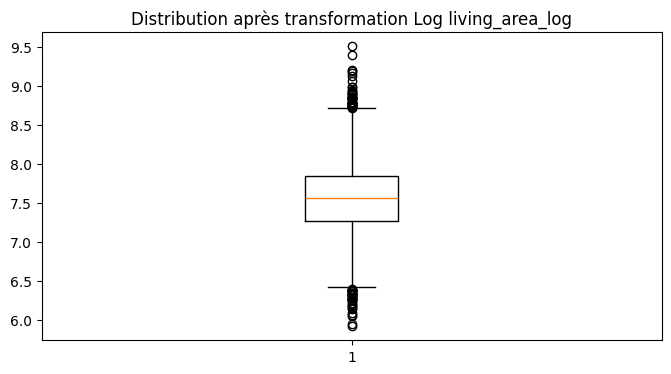

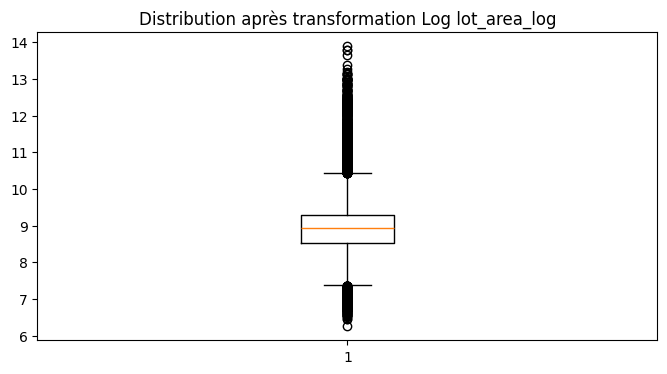

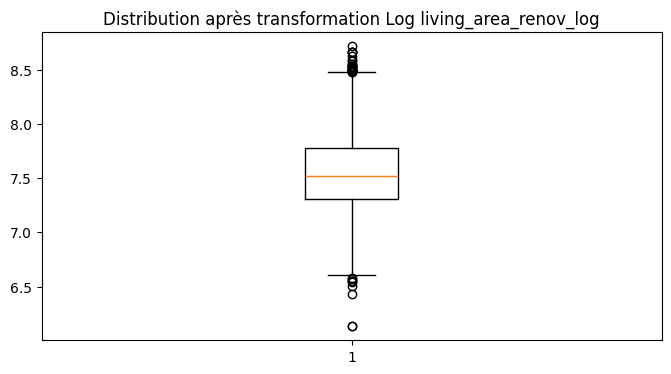

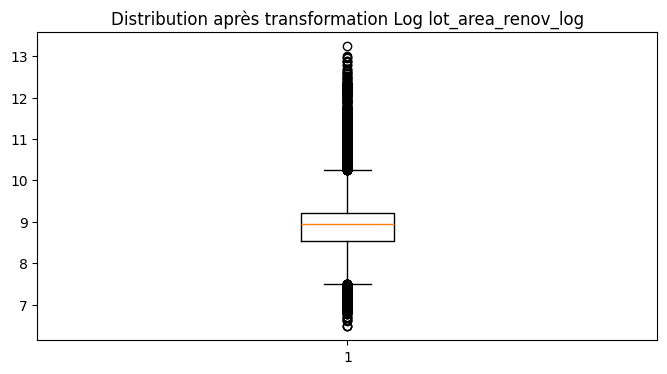

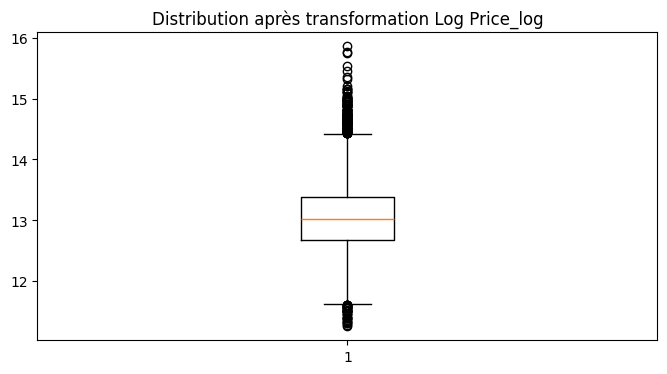

In [17]:
data = df[['living_area_log', 'lot_area_log', 'living_area_renov_log', 'lot_area_renov_log', 'Price_log']]
#Boxplot
data_cols = data.columns
for i in data_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(x=data[i])
    plt.title(f'Distribution après transformation Log {i}')
    plt.show()

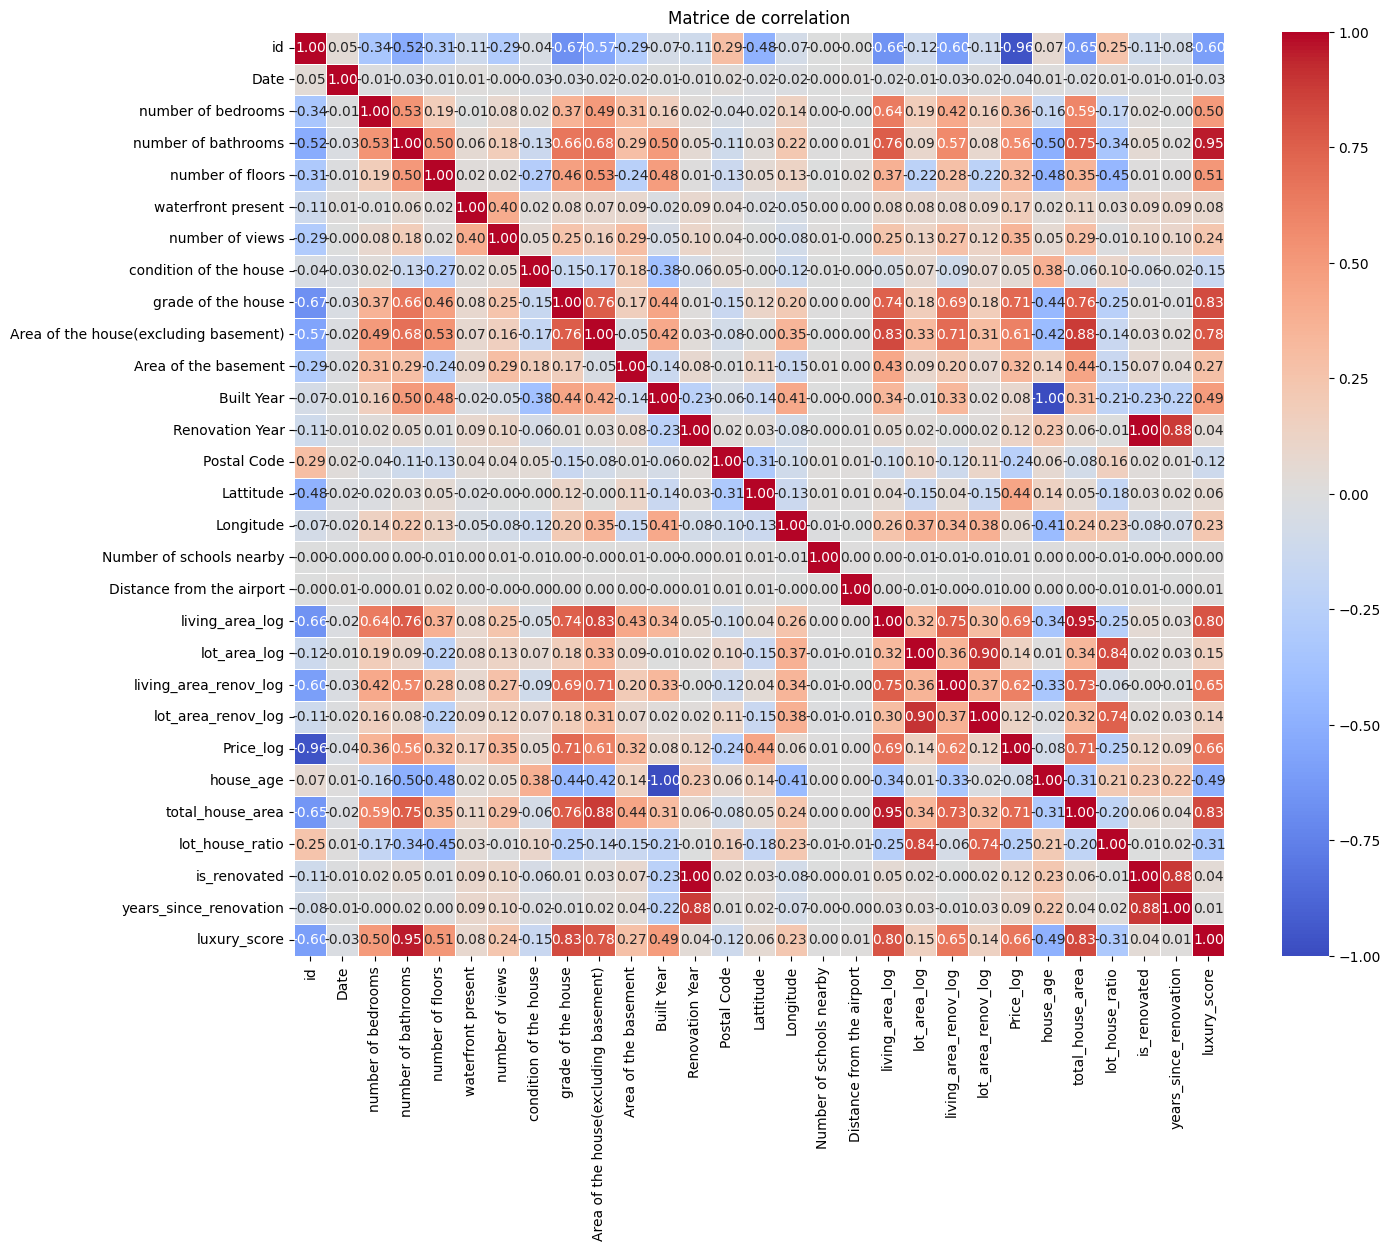

In [18]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths = 0.5,
            center = 0
           )
plt.title('Matrice de correlation')
plt.show()

# Test statistique de Pearson

In [19]:
#Test statistique de Pearson
from scipy import stats

def Test_pearson(col1, col2):
    corr, p_value = stats.pearsonr(df[col1], df[col2])
    print(f"Variable: {col1}")
    print(f"Corrélation: {corr:.2f}, P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Relation significative : On garde cette variable.\n")
    else:
        print("Relation non significative : On peut envisager de la supprimer.\n")

# Test sur tes variables les plus impactantes
for col in ['number of bedrooms', 'number of bathrooms', 'grade of the house', 'number of views', 'total_house_area', 'Lattitude', 'living_area_log',
           'living_area_renov_log', 'house_age','lot_house_ratio', 'is_renovated', 'years_since_renovation', 'luxury_score']:
    Test_pearson(col, 'Price_log')

Variable: number of bedrooms
Corrélation: 0.36, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: number of bathrooms
Corrélation: 0.56, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: grade of the house
Corrélation: 0.71, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: number of views
Corrélation: 0.35, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: total_house_area
Corrélation: 0.71, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: Lattitude
Corrélation: 0.44, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: living_area_log
Corrélation: 0.69, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: living_area_renov_log
Corrélation: 0.62, P-value: 0.0000
Relation significative : On garde cette variable.

Variable: house_age
Corrélation: -0.08, P-value: 0.0000
Relation significative : On garde cet

In [20]:
df.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'Number of schools nearby', 'Distance from the airport',
       'living_area_log', 'lot_area_log', 'living_area_renov_log',
       'lot_area_renov_log', 'Price_log', 'house_age', 'total_house_area',
       'lot_house_ratio', 'is_renovated', 'years_since_renovation',
       'luxury_score'],
      dtype='object')

# Standardisation des données & Feature Selection

In [21]:
from sklearn.preprocessing import RobustScaler

# Sélection des variables
features = ['number of bedrooms', 'number of bathrooms', 'number of views', 'grade of the house', 'total_house_area', 'Lattitude', 'living_area_log',
           'living_area_renov_log', 'house_age', 'lot_house_ratio', 'is_renovated', 'years_since_renovation']

# Initialisation du scaler
scaler = RobustScaler()

#Application de la standardisation
# On crée un nouveau DataFrame pour ne pas écraser les données originales tout de suite
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

In [22]:
# Vérification des nouvelles échelles
print("Médianes après RobustScaler (devraient être proches de 0) :")
print(df_scaled[features].median().round(2))

Médianes après RobustScaler (devraient être proches de 0) :
number of bedrooms        0.0
number of bathrooms       0.0
number of views           0.0
grade of the house        0.0
total_house_area          0.0
Lattitude                 0.0
living_area_log           0.0
living_area_renov_log     0.0
house_age                 0.0
lot_house_ratio           0.0
is_renovated              0.0
years_since_renovation    0.0
dtype: float64


# Division (Train/Test split)

In [23]:
from sklearn.model_selection import train_test_split
# X : les 5 variables indépendantes standardisées
# y : la variable cible  en log

X = df_scaled[features]
y = df['Price_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=5)

# Régression Linéaire

In [24]:
from sklearn.linear_model import LinearRegression

# Création du modèle
model_lr = LinearRegression()

# Apprentissage
model_lr.fit(X_train, y_train)

LinearRegression()

In [25]:
# Prédiction sur le test set
y_pred = model_lr.predict(X_test)

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calcul des métriques de base
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Calcul du R² Ajusté
# n = nombre d'observations, p = nombre de variables
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# 4. Affichage propre des résultats
print(f"R2 (Précision relative): {r2:.4f}")
print(f"R2 Ajusté: {adj_r2:.4f}")
print(f"MAE (Erreur moyenne abs): {mae:.4f}")
print(f"RMSE (Erreur type): {rmse:.4f}")
print(f"MSE (Erreur au carré): {mse:.4f}")

R2 (Précision relative): 0.7852
R2 Ajusté: 0.7843
MAE (Erreur moyenne abs): 0.1923
RMSE (Erreur type): 0.2493
MSE (Erreur au carré): 0.0621


**Interprétation des résultats:**

- **R2 = 0.7852** et **R2 ajusté = 0.7843**, signifie que mes 12 variables utilisées pour créer le modèle sont toutes utiles et qu'ils expliquent environ **79 %** de la variation des prix des maisons en Inde.
- **MAE =  0.1923** sur le log du prix signifie qu'en moyenne, le modèle se trompe d'environ **19 %** sur le prix réel de la maison.
- Comme la **RMSE (0.2493)** est peu élevée que la **MAE (0.1923)**. Cela indique que le modèle fait de minimes erreurs sur certaines maisons spécifiques.

# Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialisation
model_rf = RandomForestRegressor(n_estimators=100, random_state=5)

# Entrainement
model_rf.fit (X_train, y_train)

RandomForestRegressor(random_state=5)

In [28]:
# Prediction
y_pred_rf = model_rf.predict(X_test)

In [29]:
# Métriques
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R2: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")

R2: 0.8690
MAE: 0.1378
RMSE: 0.1946


**Interprétation des résultats:**

- **R2: 0.8690**: signifie que mes 12 variables utilisées pour créer le modèle sont toutes utiles expliquent environ **87 %** de la variation des prix des maisons en Inde.
- Une **MAE: 0.1378** sur le log du prix signifie qu'en moyenne, le modèle se trompe d'environ **14 %** sur le prix réel de la maison.
- Comme la **RMSE (0.1956)** est un peu plus élevée que la **MAE (0.1378)**. Cela indique que le modèle fait de petites erreurs sur certaines maisons spécifiques.

# AdaBoost

In [30]:
from sklearn.ensemble import AdaBoostRegressor

# Initiation
model_ada = AdaBoostRegressor(n_estimators=100, random_state=5)

# Entrainement
model_ada.fit(X_train, y_train)

AdaBoostRegressor(n_estimators=100, random_state=5)

In [31]:
# Prédiction
y_pred_ada = model_ada.predict(X_test)

mae_ada = mean_absolute_error(y_test, y_pred_ada)
# Métriques
print(f"R2: {r2_score(y_test, y_pred_ada):.4f}")
print(f"MAE: {mae_ada:.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ada)):.4f}")

R2: 0.7692
MAE: 0.2035
RMSE: 0.2584


**Interprétation des résultats:**

- **R2: 0.7692**: signifie que mes 12 variables utilisées pour créer le modèle sont toutes utiles expliquent environ **77 %** de la variation des prix des maisons en Inde.
- Une **MAE: 0.2035** sur le log du prix signifie qu'en moyenne, le modèle se trompe d'environ **20 %** sur le prix réel de la maison.
- Comme la **RMSE (0.2584)** est nettement plus élevée que la **MAE (0.2035)**. Cela indique que le modèle fait de grosses erreurs sur certaines maisons spécifiques.

# XGBOOST

In [32]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialisation
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=5)

# Entrainement
model_gb.fit(X_train, y_train)


GradientBoostingRegressor(random_state=5)

In [33]:
# Prédiction
y_pred_gb = model_gb.predict(X_test)

# Calcul des métriques
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"R2 : {r2_gb:.4f}")
print(f"MAE : {mae_gb:.4f}")
print(f"RMSE : {rmse_gb:.4f}")

R2 : 0.8661
MAE : 0.1437
RMSE : 0.1968


**Interprétation des résultats:**

- **R2: 0.8661**: signifie que mes 12 variables utilisées pour créer le modèle sont toutes utiles expliquent environ **87 %** de la variation des prix des maisons en Inde.
- Une **MAE: 0.1437** sur le log du prix signifie qu'en moyenne, le modèle se trompe d'environ **14 %** sur le prix réel de la maison.
- Comme la **RMSE (0.1968)** est un plus élevée que la **MAE (0.1437)**. Cela indique que le modèle fait de erreurs pas très grandes sur certaines maisons spécifiques.

# Validation croisée

In [34]:
from sklearn.model_selection import KFold, cross_val_score

In [35]:
# 5-Fold Cross Validation pour la Régression Linéaire
cv_lr = cross_val_score(model_lr, X, y, cv=5, scoring='r2')

print("RÉGRESSION LINÉAIRE")
print(f"Scores : {cv_lr}")
print(f"Moyenne R2 : {cv_lr.mean():.4f}")
print(f"Écart-type  : {cv_lr.std():.4f}")

RÉGRESSION LINÉAIRE
Scores : [0.76771561 0.77530899 0.7688619  0.77535369 0.76969013]
Moyenne R2 : 0.7714
Écart-type  : 0.0033


In [36]:
# 5-Fold Cross Validation pour Random Forest
cv_rf = cross_val_score(model_rf, X, y, cv=5, scoring='r2')

print("RANDOM FOREST")
print(f"Scores : {cv_rf}")
print(f"Moyenne R2 : {cv_rf.mean():.4f}")
print(f"Écart-type  : {cv_rf.std():.4f}")

RANDOM FOREST
Scores : [0.86517838 0.86691357 0.86532163 0.865517   0.85913093]
Moyenne R2 : 0.8644
Écart-type  : 0.0027


In [37]:
# 5-Fold Cross Validation pour AdaBoost
cv_ada = cross_val_score(model_ada, X, y, cv=5, scoring='r2')

print("ADABOOST")
print(f"Scores : {cv_ada}")
print(f"Moyenne R2 : {cv_ada.mean():.4f}")
print(f"Écart-type  : {cv_ada.std():.4f}")

ADABOOST
Scores : [0.76996955 0.75864617 0.75839217 0.72757804 0.73657653]
Moyenne R2 : 0.7502
Écart-type  : 0.0157


In [38]:
# 5-Fold Cross Validation pour Gradient Boosting
cv_gb = cross_val_score(model_gb, X, y, cv=5, scoring='r2')

print("XGBOOST")
print(f"Scores : {cv_gb}")
print(f"Moyenne R² : {cv_gb.mean():.4f}")
print(f"Écart-type  : {cv_gb.std():.4f}")

XGBOOST
Scores : [0.85587106 0.8643744  0.85973642 0.86008909 0.85582033]
Moyenne R² : 0.8592
Écart-type  : 0.0032


/tmp/ipykernel_610/3411303877.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


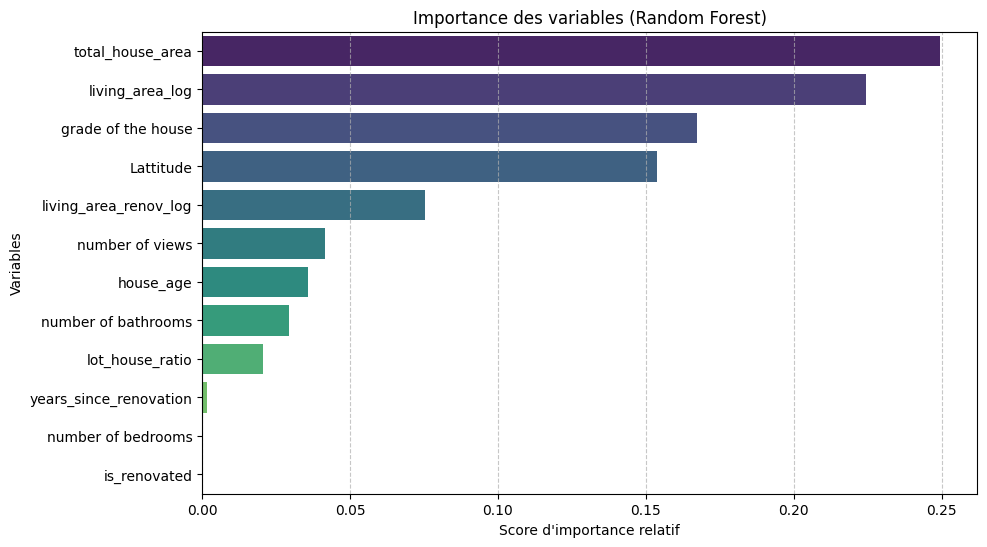

Détails des importances :
                   Feature  Importance
4         total_house_area    0.249542
6          living_area_log    0.224598
3       grade of the house    0.167267
5                Lattitude    0.153772
7    living_area_renov_log    0.075323
2          number of views    0.041595
8                house_age    0.035906
1      number of bathrooms    0.029320
9          lot_house_ratio    0.020693
11  years_since_renovation    0.001749
0       number of bedrooms    0.000234
10            is_renovated    0.000000


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Extraire les importances du modèle Gradient Boosting
importances = model_ada.feature_importances_
feature_names = X.columns

# 2. Créer un DataFrame pour faciliter la manipulation
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Trier par importance décroissante
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('Importance des variables (Random Forest)')
plt.xlabel('Score d\'importance relatif')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. Afficher les valeurs exactes pour ton rapport
print("Détails des importances :")
print(feature_importance_df)

# Grid Search - Random Forest

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


In [41]:
#  Définition de la grille de paramètres
# On teste la profondeur des arbres et le nombre d'arbres
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None] # Nombre de variables à regarder pour chaque split
}

#  Initialisation du Grid Search
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Entraînement sur tes 14 variables
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=1)

In [42]:
# 4. Affichage des résultats
print("OPTIMISATION RANDOM FOREST TERMINÉE")
print(f"Meilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur Score R2 (CV) : {grid_search_rf.best_score_:.4f}")

# 5. Sauvegarder le meilleur modèle pour tes prédictions futures
best_rf_model = grid_search_rf.best_estimator_

OPTIMISATION RANDOM FOREST TERMINÉE
Meilleurs paramètres : {'max_depth': None, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 300}
Meilleur Score R2 (CV) : 0.8640


Grid Seaech CV, nous permet de voir que les meilleurs parametres de notre modèle sont: **max_depth: None**, **max_features: None**, **min_samples_split: 5**, **n_estimators: 300** et grace a ces paramètres, notre modèle arrive a une performance maximale de **86.40 %**